In [ ]:
# CELL 1: Setup & GPU Verification
!pip install deepforest rasterio pillow pandas tqdm matplotlib scikit-learn -q

import torch
import os

print("=" * 50)
if torch.cuda.is_available():
    print(f"✅ GPU Active: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ WARNING: GPU not detected! Go to Runtime -> Change runtime type -> Select T4 GPU.")
print("=" * 50)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.7/604.7 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# CELL 2: Mount Drive & Extract Data
from google.colab import drive
import shutil
import pandas as pd

# 1. Mount Drive
drive.mount('/content/drive',force_remount=True)

# 2. Path to your zip file on Google Drive (adjust if inside a folder)
ZIP_PATH = "/content/drive/MyDrive/unified_dataset_version1.zip"
EXTRACT_DEST = "/content/"

print(f"📦 Extracting {ZIP_PATH} to local SSD...")
shutil.unpack_archive(ZIP_PATH, EXTRACT_DEST)
print("✅ Extraction complete!")

# 3. Verify files and splits
DATA_DIR = "/content/unified_dataset"
IMG_DIR = os.path.join(DATA_DIR, "images")

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

total_imgs = len(os.listdir(IMG_DIR))
print("\n" + "=" * 45)
print(f"📁 Local Images Found: {total_imgs}")
print(f"📊 Train Set: {len(train_df['image_path'].unique())} images | {len(train_df)} trees")
print(f"📊 Val Set:   {len(val_df['image_path'].unique())} images | {len(val_df)} trees")
print(f"📊 Test Set:  {len(test_df['image_path'].unique())} images | {len(test_df)} trees")
print("=" * 45)

Mounted at /content/drive
📦 Extracting /content/drive/MyDrive/unified_dataset_version1.zip to local SSD...
✅ Extraction complete!

📁 Local Images Found: 14688
📊 Train Set: 4960 images | 121193 trees
📊 Val Set:   628 images | 18509 trees
📊 Test Set:  606 images | 15245 trees


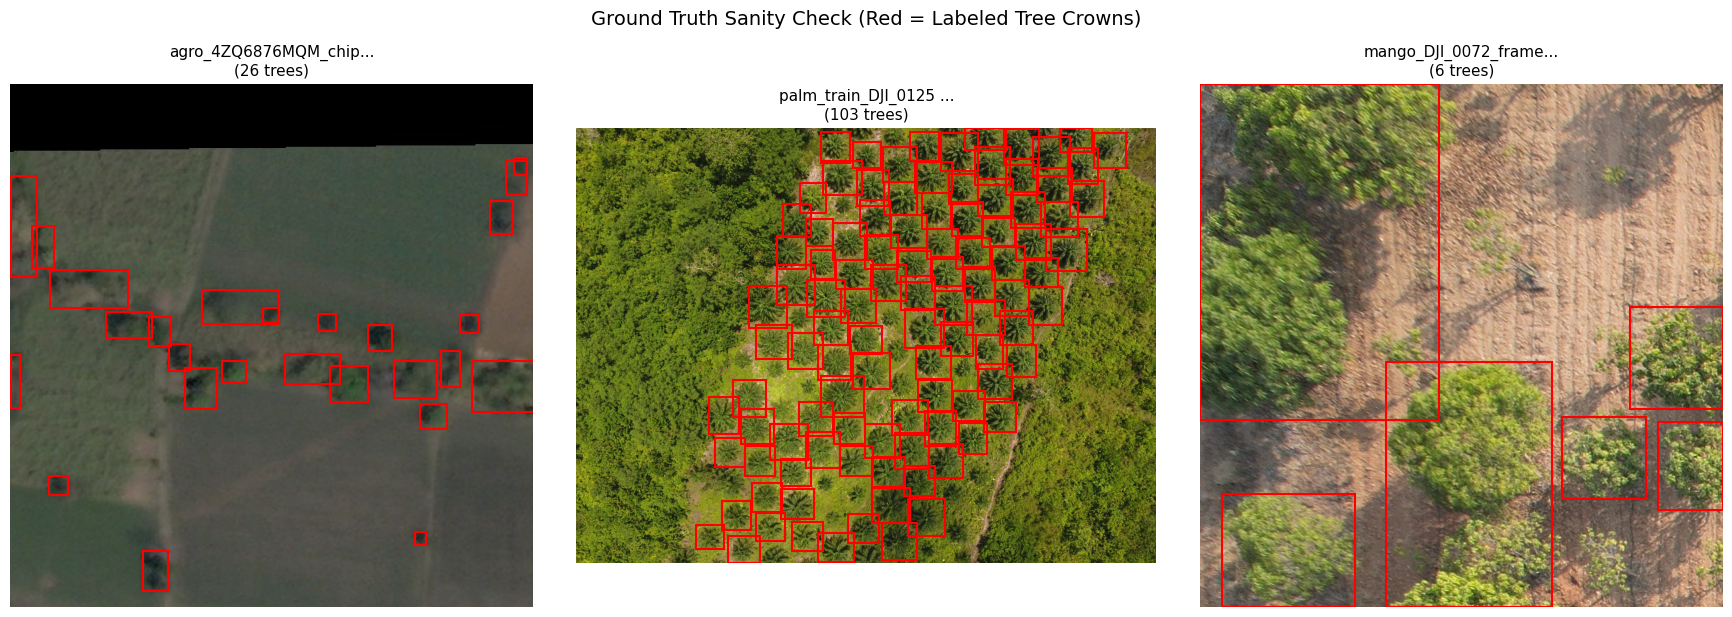

In [ ]:
# CELL 3: Multi-Dataset Visual Sanity Check
#plots 3 images and their bounding boxes to visually check whether alignment after
#is done right
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

# Select 3 distinct images (ideally 1 agro, 1 palm, 1 mango if present)
sample_images = []
for prefix in ['agro', 'palm', 'mango']:
    matches = [img for img in train_df['image_path'].unique() if img.startswith(prefix)]
    if matches:
        sample_images.append(random.choice(matches))

# If specific prefixes aren't found, pick 3 random images
while len(sample_images) < 3:
    sample_images.append(random.choice(train_df['image_path'].unique()))

fig, axes = plt.subplots(1, len(sample_images), figsize=(18, 6))

for ax, img_name in zip(axes, sample_images):
    img_path = os.path.join(IMG_DIR, img_name)
    img = Image.open(img_path)
    ax.imshow(img)

    # Overlay ground-truth bounding boxes
    boxes = train_df[train_df['image_path'] == img_name]
    for _, row in boxes.iterrows():
        w = row['xmax'] - row['xmin']
        h = row['ymax'] - row['ymin']
        rect = patches.Rectangle((row['xmin'], row['ymin']), w, h,
                                 linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    ax.set_title(f"{img_name[:20]}...\n({len(boxes)} trees)", fontsize=11)
    ax.axis('off')

plt.suptitle("Ground Truth Sanity Check (Red = Labeled Tree Crowns)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 4: Model Configuration
from deepforest import main

# 1. Initialize with pre-trained global weights
model = main.deepforest()
#model.use_release() #this breaks new deepforest

# 2. Point to the extracted CSVs and Image directory
model.config["train"]["csv_file"] = os.path.join(DATA_DIR, "train.csv")
model.config["train"]["root_dir"] = IMG_DIR

model.config["validation"]["csv_file"] = os.path.join(DATA_DIR, "val.csv")
model.config["validation"]["root_dir"] = IMG_DIR

# 3. Hyperparameters tuned for Colab T4
model.config["epochs"] = 10           # 10 epochs takes ~15-20 mins
model.config["batch_size"] = 4       # Safe for GPU memory with 1920px bounds
model.config["workers"] = 2          # Matches Colab CPU cores
model.config["train"]["lr"] = 0.0001 # Fine-tuning learning rate
model.config["save_snapshot"] = True

print("✅ DeepForest configured for T4 GPU training!")

config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B /  129MB            

model.safetensors: downloading bytes:           |  0.00B            

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ DeepForest configured for T4 GPU training!


In [ ]:
# CELL 5: Training & Automatic Drive Backup
print("🚀 Starting DeepForest Fine-Tuning on Indian Tree Canopies...")
model.create_trainer()
model.trainer.fit(model)

# 1. Save locally
LOCAL_MODEL_PATH = "/content/deepforest_indian_canopy.pt"
model.save_model(LOCAL_MODEL_PATH)
print(f"💾 Model saved locally to: {LOCAL_MODEL_PATH}")

# 2. Backup to Google Drive so you never lose weights if Colab disconnects
DRIVE_BACKUP_PATH = "/content/drive/MyDrive/deepforest_indian_canopy.pt"
shutil.copy(LOCAL_MODEL_PATH, DRIVE_BACKUP_PATH)
print(f"🛡️ Permanent backup saved to Drive: {DRIVE_BACKUP_PATH}")

🚀 Starting DeepForest Fine-Tuning on Indian Tree Canopies...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model                   │ RetinaNetHub          │ 32.1 M │ eval  │     0 │
│ 1 │ iou_metric              │ IntersectionOverUnion │      0 │ train │     0 │
│ 2 │ mAP_metric              │ MeanAveragePrecision  │      0 │ train │     0 │
│ 3 │ empty_frame_accuracy    │ BinaryAccuracy        │      0 │ train │     0 │
│ 4 │ precision_recall_metric │ RecallPrecision       │      0 │ train │     0 │
└───┴─────────────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 31.9 M                                                                                           
Non-trainable params: 222 K                                                                                        
Total params: 32.1 M                                                                                               
Total estimated model params size (MB): 128.592                                                                    
Modules in train mode: 4                                                                                           
Modules in eval mode: 202                                                                                          
Total FLOPs: 0

Output()

...

/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100
detections in a single image. This means that certain detections with the lowest scores will be ignored, that may 
have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use
case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100
detections in a single image. This means that certain detections with the lowest scores will be ignored, that may 
have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use
case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


💾 Model saved locally to: /content/deepforest_indian_canopy.pt
🛡️ Permanent backup saved to Drive: /content/drive/MyDrive/deepforest_indian_canopy.pt


In [ ]:
# CELL 6: Quantitative Test Set Evaluation
print("🧪 Evaluating fine-tuned model on unseen Test Set...")

test_csv_path = os.path.join(DATA_DIR, "test.csv")
results = model.evaluate(csv_file=test_csv_path, root_dir=IMG_DIR, iou_threshold=0.5)

precision = results['box_precision']
recall = results['box_recall']
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("\n" + "=" * 45)
print("📊 UNSEEN TEST SET BENCHMARK RESULTS")
print("=" * 45)
print(f"Bounding Box Precision : {precision:.4f} ({precision*100:.1f}%)")
print(f"Bounding Box Recall    : {recall:.4f} ({recall*100:.1f}%)")
print(f"F1-Score               : {f1:.4f}")
print("=" * 45)

🧪 Evaluating fine-tuned model on unseen Test Set...


/tmp/ipykernel_1804/973381808.py:5: DeprecationWarning: deepforest.evaluate() is deprecated and will be removed in a future version. Please use trainer.validate() instead to get evaluation statistics during training.
  results = model.evaluate(csv_file=test_csv_path, root_dir=IMG_DIR, iou_threshold=0.5)
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()


📊 UNSEEN TEST SET BENCHMARK RESULTS
Bounding Box Precision : 0.3829 (38.3%)
Bounding Box Recall    : 0.6351 (63.5%)
F1-Score               : 0.4778


Analyzing tree counts on test subset...

📈 Mean Absolute Error (MAE): 12.60 trees per image


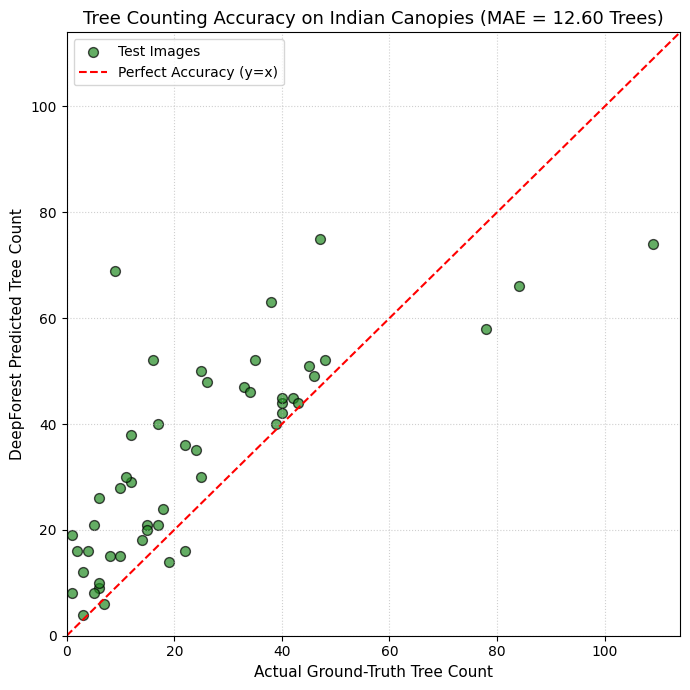

In [ ]:
# CELL 7: Tree Count Error Analysis (Updated - No return_plot)
import numpy as np
import matplotlib.pyplot as plt

test_images = test_df['image_path'].unique()
sample_test_subset = test_images[:50]  # Benchmark over 50 test images

actual_counts = []
predicted_counts = []

print("Analyzing tree counts on test subset...")
for img_name in sample_test_subset:
    img_path = os.path.join(IMG_DIR, img_name)

    # 1. Ground truth count
    gt_count = len(test_df[test_df['image_path'] == img_name])

    # 2. Model prediction (clean call - returns DataFrame directly)
    preds = model.predict_image(path=img_path)
    pred_count = len(preds) if (preds is not None and not preds.empty) else 0

    actual_counts.append(gt_count)
    predicted_counts.append(pred_count)

actual_counts = np.array(actual_counts)
predicted_counts = np.array(predicted_counts)

mae = np.mean(np.abs(actual_counts - predicted_counts))
print(f"\n📈 Mean Absolute Error (MAE): {mae:.2f} trees per image")

# Plot Actual vs. Predicted Tree Counts
plt.figure(figsize=(7, 7))
plt.scatter(actual_counts, predicted_counts, color='forestgreen', alpha=0.7, edgecolors='k', s=50, label='Test Images')
max_val = max(actual_counts.max(), predicted_counts.max()) + 5
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Accuracy (y=x)')

plt.title(f"Tree Counting Accuracy on Indian Canopies (MAE = {mae:.2f} Trees)", fontsize=13)
plt.xlabel("Actual Ground-Truth Tree Count", fontsize=11)
plt.ylabel("DeepForest Predicted Tree Count", fontsize=11)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

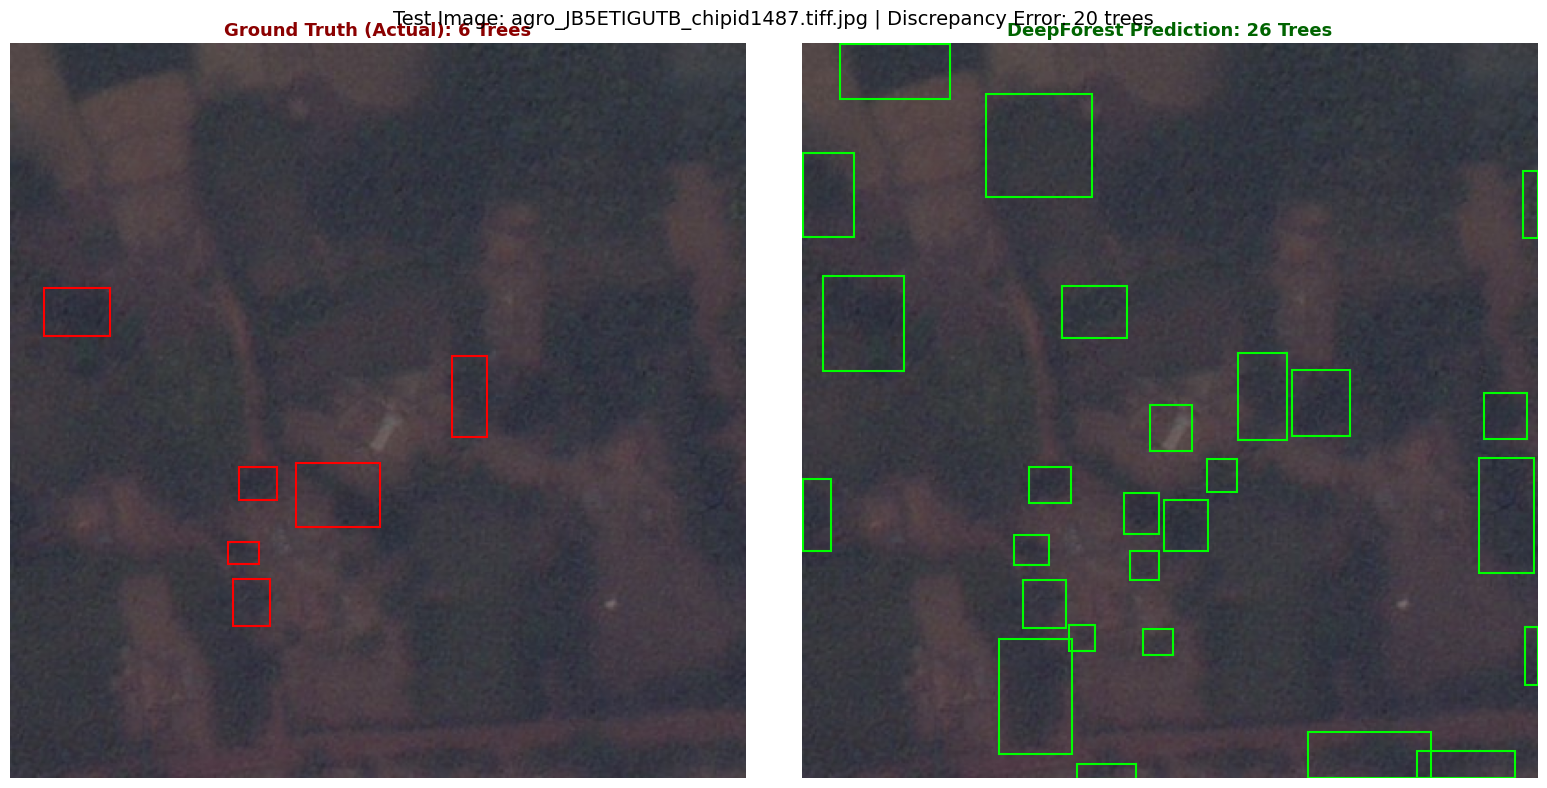

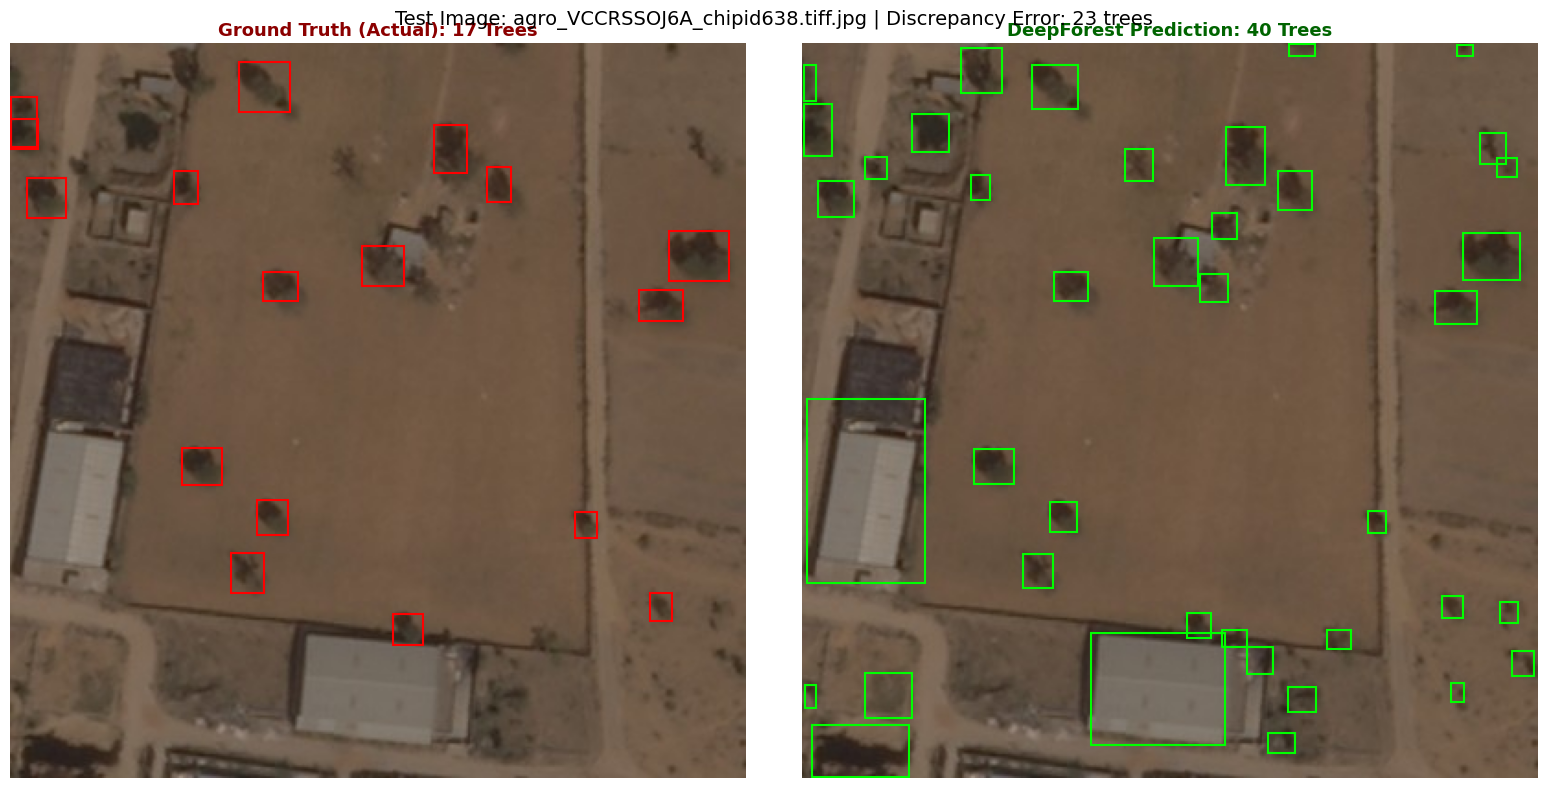

In [ ]:
# CELL 8: Visual Inference Comparison (Updated - Bulletproof Plotting)
import random
from PIL import Image
import matplotlib.patches as patches

# Pick 2 random test images to evaluate
demo_images = random.sample(list(test_images), 2)

for demo_name in demo_images:
    demo_path = os.path.join(IMG_DIR, demo_name)
    gt_boxes = test_df[test_df['image_path'] == demo_name]

    # Run prediction
    pred_boxes = model.predict_image(path=demo_path)
    pred_count = len(pred_boxes) if (pred_boxes is not None and not pred_boxes.empty) else 0
    actual_count = len(gt_boxes)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # --- LEFT: GROUND TRUTH (RED BOXES) ---
    img_gt = Image.open(demo_path)
    axes[0].imshow(img_gt)
    for _, row in gt_boxes.iterrows():
        w = row['xmax'] - row['xmin']
        h = row['ymax'] - row['ymin']
        rect = patches.Rectangle((row['xmin'], row['ymin']), w, h,
                                 linewidth=1.5, edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
    axes[0].set_title(f"Ground Truth (Actual): {actual_count} Trees", fontsize=13, color='darkred', fontweight='bold')
    axes[0].axis('off')

    # --- RIGHT: DEEPFOREST PREDICTION (LIME GREEN BOXES) ---
    img_pred = Image.open(demo_path)
    axes[1].imshow(img_pred)
    if pred_boxes is not None and not pred_boxes.empty:
        for _, row in pred_boxes.iterrows():
            w = row['xmax'] - row['xmin']
            h = row['ymax'] - row['ymin']
            rect = patches.Rectangle((row['xmin'], row['ymin']), w, h,
                                     linewidth=1.5, edgecolor='lime', facecolor='none')
            axes[1].add_patch(rect)
    axes[1].set_title(f"DeepForest Prediction: {pred_count} Trees", fontsize=13, color='darkgreen', fontweight='bold')
    axes[1].axis('off')

    error = abs(actual_count - pred_count)
    plt.suptitle(f"Test Image: {demo_name} | Discrepancy Error: {error} trees", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

In [ ]:
# TEST THIS CELL: Threshold Filtering Test
import numpy as np
import matplotlib.pyplot as plt

CONFIDENCE_THRESH = 0.40  # Only keep detections with >= 40% confidence

filtered_actual = []
filtered_predicted = []

for img_name in sample_test_subset:
    img_path = os.path.join(IMG_DIR, img_name)
    gt_count = len(test_df[test_df['image_path'] == img_name])

    preds = model.predict_image(path=img_path)

    if preds is not None and not preds.empty:
        # Filter out weak predictions!
        confident_preds = preds[preds['score'] >= CONFIDENCE_THRESH]
        pred_count = len(confident_preds)
    else:
        pred_count = 0

    filtered_actual.append(gt_count)
    filtered_predicted.append(pred_count)

filtered_actual = np.array(filtered_actual)
filtered_predicted = np.array(filtered_predicted)

new_mae = np.mean(np.abs(filtered_actual - filtered_predicted))
print(f"🔥 Original MAE: 13.94 trees")
print(f"✨ New MAE with Score >= {CONFIDENCE_THRESH}: {new_mae:.2f} trees!")

🔥 Original MAE: 13.94 trees
✨ New MAE with Score >= 0.4: 23.46 trees!


In [ ]:
# The Threshold Sweep Curve
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
mae_results = []

for t in thresholds:
    errors = []
    for img_name in sample_test_subset:
        gt_count = len(test_df[test_df['image_path'] == img_name])
        img_path = os.path.join(IMG_DIR, img_name)
        preds = model.predict_image(path=img_path)

        if preds is not None and not preds.empty:
            count = len(preds[preds['score'] >= t])
        else:
            count = 0
        errors.append(abs(gt_count - count))

    avg_mae = np.mean(errors)
    mae_results.append(avg_mae)
    print(f"Threshold: {t:.2f} -> MAE: {avg_mae:.2f} trees")

# Find the winner
best_idx = np.argmin(mae_results)
print(f"\n🏆 Optimal Mathematical Threshold: {thresholds[best_idx]} (MAE = {mae_results[best_idx]:.2f})")

Threshold: 0.10 -> MAE: 12.60 trees
Threshold: 0.15 -> MAE: 9.44 trees
Threshold: 0.20 -> MAE: 9.70 trees
Threshold: 0.25 -> MAE: 13.06 trees
Threshold: 0.30 -> MAE: 17.22 trees
Threshold: 0.35 -> MAE: 21.34 trees
Threshold: 0.40 -> MAE: 23.46 trees

🏆 Optimal Mathematical Threshold: 0.15 (MAE = 9.44)
